# Session 26 Plotting using Seaborn Part-2
This Session is a continuation of the last Session on Seaborn.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# read datasets
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')

## 4. Categorical Plots

Categorical plots are used when **one or more variables are categorical in nature**. These plots help us:

* Compare distributions across categories
* Analyze central tendency within groups
* Observe spread and variability
* Perform grouped statistical comparisons

Categorical plots in Seaborn can broadly be divided into three types:

1. Categorical Scatter Plots
2. Categorical Distribution Plots
3. Categorical Estimate Plots

---

# Categorical Scatter Plot

Since these are scatter-type plots, they perform **bivariate analysis**, where:

* One variable is categorical
* One variable is quantitative

Plots under this category:

* Stripplot
* Swarmplot

---

## Stripplot

A Stripplot is very similar to a scatter plot.

Difference:

* Scatter plot → Both variables are numerical
* Stripplot → One variable is categorical and the other is numerical

It shows individual data points for each category.

---

### Axes-Level Stripplot

```python
# axes level stripplot
sns.stripplot(data=tips, x='day', y='total_bill', hue='sex')
```

---

### Figure-Level Stripplot Using `catplot`

```python
# figure level stripplot using catplot
sns.catplot(data=tips, x='day', y='total_bill',
            kind='strip', hue='sex')
```

---

### Jitter Behavior

By default, Seaborn applies **jitter**, meaning:

* Points are slightly scattered horizontally.
* Improves readability.
* Prevents overlap within categories.

To disable jitter:

```python
sns.stripplot(data=tips, x='day', y='total_bill', jitter=False)
```

With `jitter=False`, all points align in a straight vertical line for each category.

---

## Swarmplot

Swarmplot is similar to stripplot but uses a different arrangement strategy.

Instead of random jitter:

* Points are arranged to avoid overlapping.
* Uses a packing algorithm.
* Ensures points do not overlap.

---

### Figure-Level Swarmplot

```python
# swarmplot figure level function
sns.catplot(data=tips, x='day', y='total_bill', kind='swarm')
```

---

### Axes-Level Swarmplot

```python
# swarmplot axes level function
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex')
```

---

### Stripplot vs Swarmplot

| Feature                 | Stripplot | Swarmplot                   |
| ----------------------- | --------- | --------------------------- |
| Jitter                  | Random    | Algorithmic non-overlapping |
| Overlapping Points      | Possible  | Avoided                     |
| Suitable for Large Data | Yes       | No                          |
| Computational Cost      | Low       | Higher                      |

Swarmplot is not suitable for large datasets because arranging non-overlapping points becomes computationally expensive.

For moderate to large datasets:

* Stripplot is preferred.
* Jitter can be disabled if needed.

---

# Categorical Distribution Plots

These plots primarily perform **univariate analysis within categories**.

They help:

* Understand distribution shape
* Detect skewness
* Identify outliers
* Compare spread across groups

Plots under this category:

* Boxplot
* Violinplot

---

## Boxplot

A Boxplot is a standardized way of displaying distribution using the **five-number summary**:

* Minimum
* First Quartile (Q1)
* Median
* Third Quartile (Q3)
* Maximum

It also highlights:

* Outliers
* Skewness
* Spread of data

---

### Axes-Level Boxplot

```python
# boxplot using axes level function
sns.boxplot(data=tips, x='sex', y='total_bill')
```

This creates two boxplots:

* One for Male
* One for Female

---

```python
# boxplot using axes level function
sns.boxplot(data=tips, x='day', y='total_bill')
```

Creates a boxplot for each day.

---

### Figure-Level Boxplot

```python
# boxplot using figure level function
sns.catplot(data=tips, x='day', y='total_bill',
            kind='box', hue='sex')
```

---

### Single Variable Boxplot

```python
# single boxplot using figure level function
sns.catplot(data=tips, y='total_bill', kind='box')
```

Useful for analyzing a single quantitative variable.

---

## Violinplot

A Violinplot can be understood as:

```id="1wlb4k"
Boxplot + KDE Plot
```

It combines:

* Boxplot summary statistics
* Smoothed density estimation

---

### Axes-Level Violinplot

```python
# violinplot using axes level function
sns.violinplot(data=tips, x='day', y='total_bill')
```

---

### Figure-Level Violinplot

```python
# violinplot using figure level function
sns.catplot(data=tips, x='day', y='total_bill',
            kind='violin')
```

---

### Violinplot with Hue

```python
# violinplot using figure level function
sns.catplot(data=tips, x='day', y='total_bill',
            kind='violin', hue='sex', split=True)
```

Here:

* By default, violins are symmetrical.
* `split=True` divides the violin.
* Each half represents a different category of `hue`.

This avoids redundant mirrored distributions and improves clarity.

---

# Categorical Estimate Plots (Central Tendency)

These plots focus on **estimating central tendency or counts** across categories.

They help measure:

* Mean
* Median
* Standard deviation
* Count
* Other aggregate statistics

Plots under this category:

* Barplot
* Pointplot
* Countplot

---

## Barplot

A Barplot performs an **aggregate computation** over a categorical variable.

By default:

* The estimator is the **mean**.

Example: Comparing average `total_bill` between Male and Female.

---

### Axes-Level Barplot

```python
# barplot using axes level function
sns.barplot(data=tips, x='sex', y='total_bill')
```

---

### Understanding Error Bars

In the center of each bar, you will see a vertical black line.

This is an **error bar**.

When multiple observations exist per category:

* Seaborn uses **bootstrapping**.
* Computes a **confidence interval** around the estimate.
* Displays it as an error bar.

Both bootstrapping and confidence intervals are statistical methods used to quantify uncertainty.

---

### The `errorbar` Parameter

The `errorbar` parameter controls:

* Whether to display confidence intervals.
* Type of interval (e.g., standard deviation, standard error).
* Can be disabled if needed.

---

### Figure-Level Barplot with Custom Estimator

```python
# barplot using figure level function
sns.catplot(data=tips, x='sex', y='total_bill',
            kind='bar', hue='smoker',
            estimator=np.std)
```

Here:

* Default estimator (mean) is replaced.
* `estimator=np.std` computes standard deviation instead.

Other possible estimators:

* `np.median`
* `np.min`
* `np.max`
* Custom functions

---

## Pointplot

A Pointplot is conceptually similar to a barplot.

Difference:

* Bars are removed.
* Points represent the estimate.
* Error bars are retained.
* Points across categories are connected.

This often provides a clearer comparison between categories.

---

### Simple Pointplot

```python
# pointplot using axes level function
sns.pointplot(data=tips, x='sex', y='total_bill')
```

---

### Pointplot with Hue and Custom Estimator

```python
# pointplot using axes level function
sns.pointplot(data=tips, x='sex', y='total_bill',
              hue='smoker', estimator=np.min)
```

This allows comparison of minimum values across grouped categories.

---

## Countplot

Countplot is a special case of barplot.

Instead of computing a statistic:

* It counts the number of observations per category.
* Similar to a histogram over a categorical variable.

---

### Axes-Level Countplot

```python
# countplot using an axes level function
sns.countplot(data=tips, x='sex', hue='day')
```

---

### Figure-Level Countplot

```python
# countplot using a figure level function
sns.catplot(data=tips, x='sex', hue='day',
            kind='count')
```

---

### Faceting with `catplot`

One major advantage of `catplot` is faceting.

```python
# faceting using catplot
sns.catplot(data=tips, x='sex', hue='day',
            kind='count', col='smoker')
```

This creates separate plots based on the `smoker` category.

---

## Key Takeaways from Categorical Plots

1. Stripplot and Swarmplot visualize raw categorical data points.
2. Boxplot and Violinplot analyze distribution within categories.
3. Barplot and Pointplot estimate central tendency.
4. Countplot shows frequency of categories.
5. `catplot()` is the figure-level function for categorical plots and supports faceting.
6. Bootstrapping and confidence intervals provide statistical reliability.

Categorical plots are fundamental for grouped analysis and are widely used in exploratory data analysis, hypothesis testing, and business reporting.

<Axes: xlabel='day', ylabel='total_bill'>

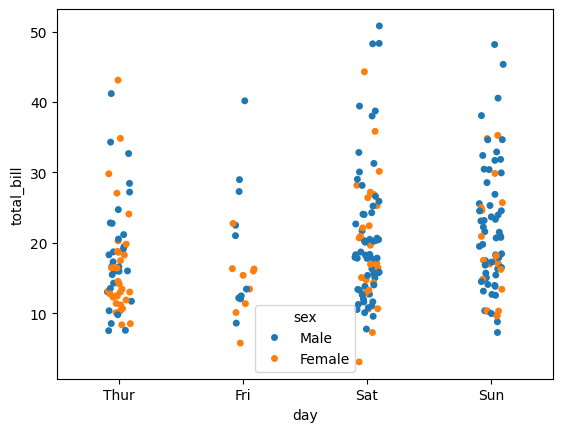

In [3]:
# axes level stripplot
sns.stripplot(data=tips, x='day', y='total_bill', hue='sex')

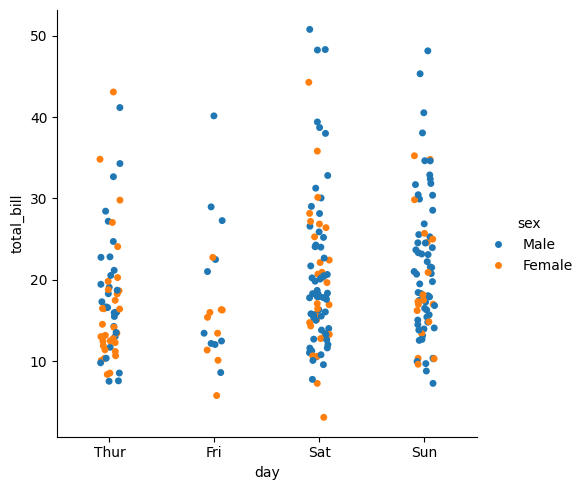

In [4]:
# figure level stripplot using catplot
sns.catplot(tips, x='day', y='total_bill', kind='strip', hue='sex')

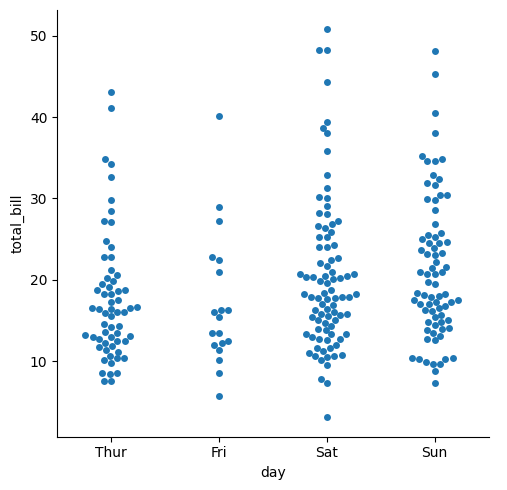

In [5]:
# swarmplot figure level function
sns.catplot(data=tips, x='day', y='total_bill', kind='swarm')

<Axes: xlabel='sex', ylabel='total_bill'>

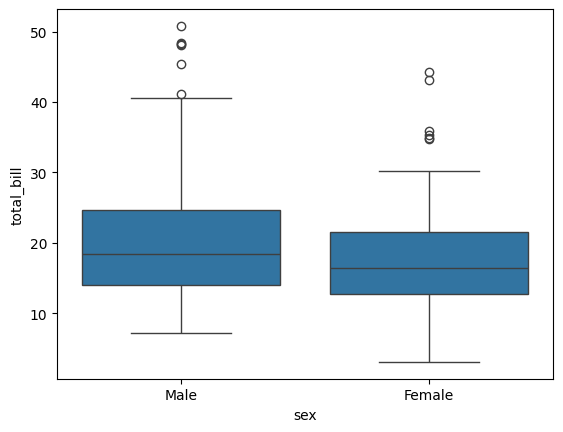

In [6]:
# boxplot using axes level function
sns.boxplot(data=tips, x='sex', y='total_bill')

<Axes: xlabel='day', ylabel='total_bill'>

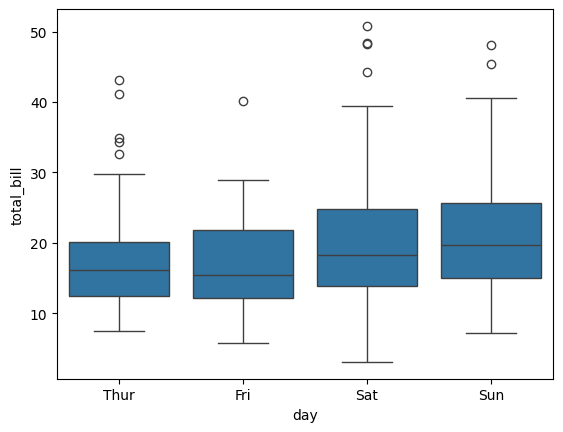

In [7]:
# boxplot using axes level function
sns.boxplot(data=tips, x='day', y='total_bill')

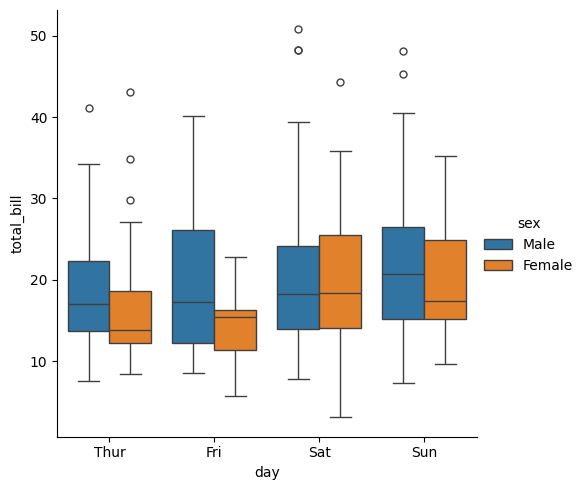

In [8]:
# boxplot using figure level function
sns.catplot(data=tips, x='day', y='total_bill', kind='box', hue='sex')

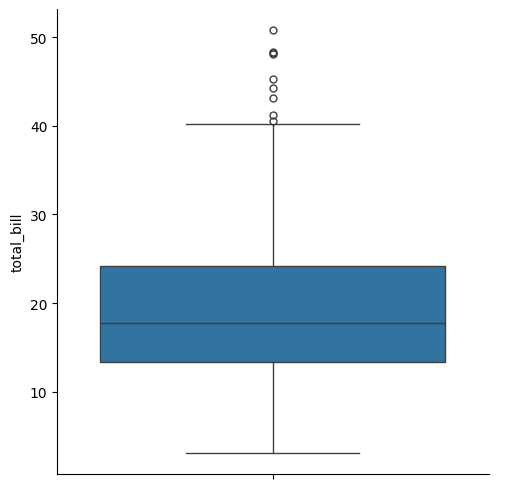

In [9]:
# boxplot using figure level function
sns.catplot(data=tips, y='total_bill', kind='box')

<Axes: xlabel='day', ylabel='total_bill'>

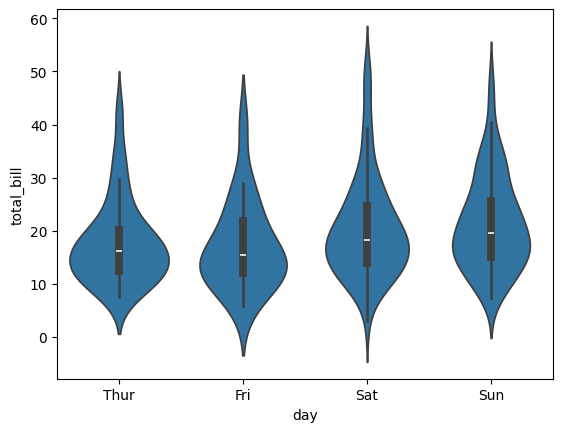

In [10]:
# violinplot using axes level function
sns.violinplot(data=tips, x='day', y='total_bill')

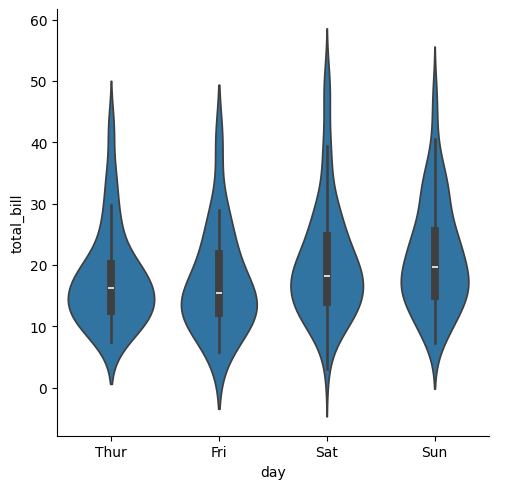

In [11]:
# violinplot using figure level function
sns.catplot(data=tips, x='day', y='total_bill', kind='violin')

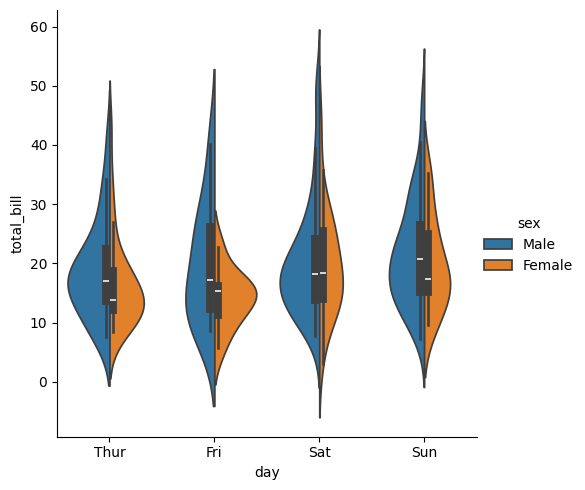

In [12]:
# violinplot using figure level function
sns.catplot(data=tips, x='day', y='total_bill', kind='violin', hue='sex', split=True)

<Axes: xlabel='sex', ylabel='total_bill'>

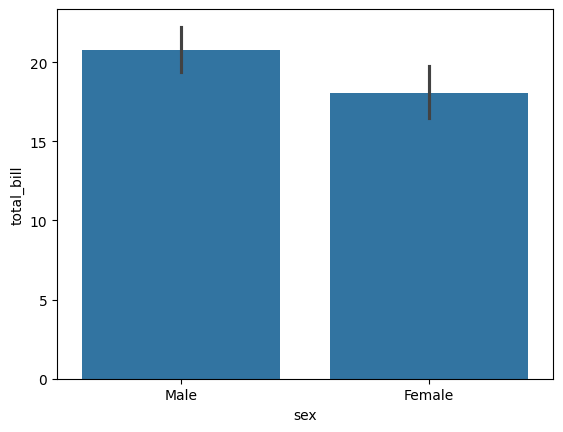

In [13]:
# barplot using axes level function
sns.barplot(data=tips, x='sex', y='total_bill')

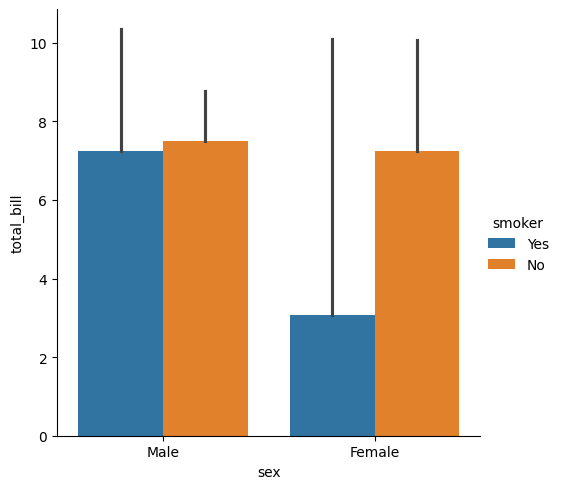

In [14]:
# barplot using axes level function
sns.catplot(data=tips, x='sex', y='total_bill', kind='bar', hue='smoker', estimator=np.min)

<Axes: xlabel='sex', ylabel='total_bill'>

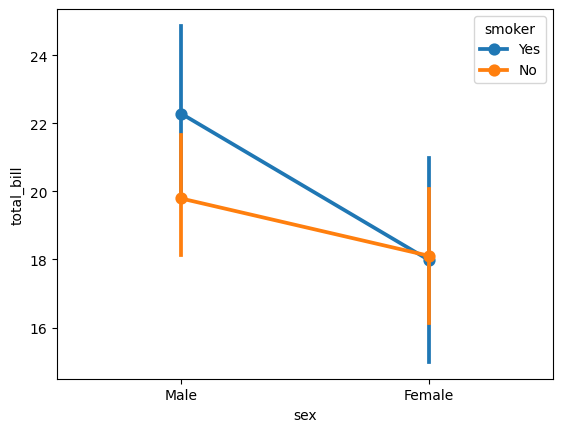

In [15]:
# barplot using axes level function
sns.pointplot(data=tips, x='sex', y='total_bill', hue='smoker')

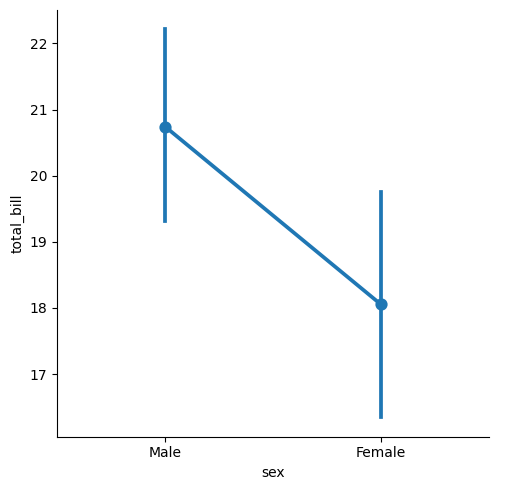

In [16]:
# pointplot using a figure level function
sns.catplot(data=tips, kind='point', x='sex', y='total_bill')

<Axes: xlabel='sex', ylabel='count'>

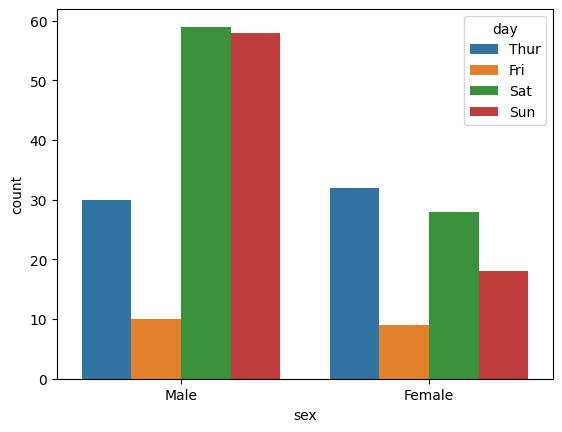

In [17]:
# countplot using an axes level function
sns.countplot(data=tips, x='sex', hue='day')

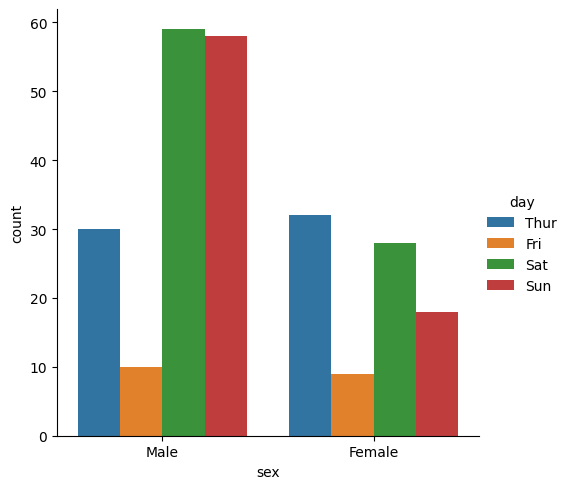

In [18]:
# countplot using a figure level function
sns.catplot(data=tips, x='sex', hue='day', kind='count')

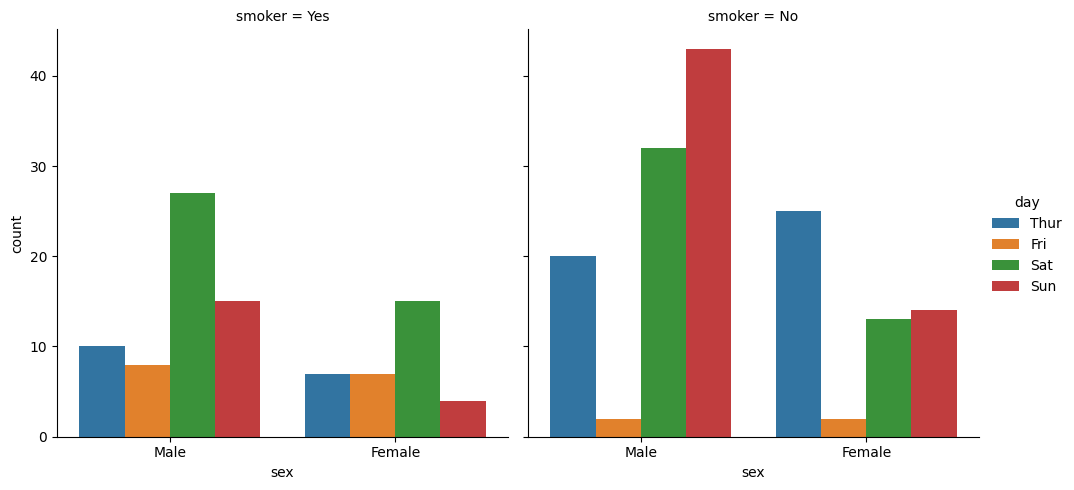

In [19]:
# faceting using catplot
sns.catplot(data=tips, x='sex', hue='day', kind='count', col='smoker')

## 5. Regression Plots

Regression plots in Seaborn are used to **visualize the relationship between variables along with a fitted regression model**. These plots are particularly useful when we want to:

* Understand how one variable influences another
* Observe trends in data
* Evaluate how well a regression model fits the data

Seaborn provides built-in utilities to both **plot the raw data and visualize the fitted regression line simultaneously**.

---

### Understanding Regression

Before discussing regression plots, it is important to understand what **regression** is.

Regression is a statistical technique used to **model the relationship between a dependent variable and one or more independent variables**.

The most common type is **Linear Regression**.

---

### Example: Hours of Study vs Marks

Suppose we have a dataset containing:

| Hours of Study | Marks |
| -------------- | ----- |
| 2              | 35    |
| 4              | 50    |
| 6              | 65    |
| 8              | 80    |

If we create a scatter plot using these variables:

* X-axis → Hours of Study
* Y-axis → Marks

We will likely observe that **as the number of study hours increases, marks also increase**. This indicates a **positive correlation** between the variables.

However, a scatter plot alone cannot answer questions such as:

> If a student studies for 5 hours, what marks can we expect?

To estimate such values, we use **Linear Regression**.

---

### Linear Regression Concept

Linear regression attempts to find the **best fitting straight line** that describes the relationship between variables.

This line is determined such that the **error between predicted values and actual data points is minimized**.

Mathematically, the regression equation is:

```
marks = m * hours + b
```

Where:

* **m** → slope of the line
* **b** → intercept on the y-axis

This equation allows us to **predict marks for any given number of study hours**.

---

### Regression Visualization in Seaborn

Seaborn simplifies this visualization process.

A regression plot:

1. Creates a **scatter plot of the observed data**
2. Fits a **regression line**
3. Displays the **confidence interval around the regression line**

This helps us visually assess how well the regression model fits the data.

---

## Types of Regression Plot Functions

Seaborn provides two main functions:

* `regplot` → Axes-level function
* `lmplot` → Figure-level function

In the simplest case, both functions:

* Plot a scatter plot between `x` and `y`
* Fit the regression model `y ~ x`
* Plot the regression line
* Show a **95% confidence interval** around the regression line

---

## regplot (Axes-Level Function)

`regplot` is an axes-level function and is used when we want to embed the regression plot within an existing matplotlib figure or subplot.

```python
# regplot using axes level function
sns.regplot(data=tips, x='total_bill', y='tip')
```

This produces:

* Scatter points representing the observations
* A regression line
* A shaded region around the line

The **faded shaded region around the regression line** represents the **95% confidence interval**, which indicates the potential range of error in the regression estimate.

---

## lmplot (Figure-Level Function)

`lmplot` is the **figure-level equivalent** of `regplot`.

It provides additional capabilities such as:

* Faceting
* Grouped regression using `hue`
* Automatic figure management

```python
# regplot using figure level function
sns.lmplot(data=tips, x='total_bill', y='tip', hue='sex')
```

Here:

* Separate regression lines are drawn for each category of `sex`.

Important distinction:

* The `hue` parameter works naturally with **figure-level functions like `lmplot`**, but not directly with the axes-level `regplot`.

---

## Residual Plot (residplot)

A **Residual Plot** visualizes the **errors made by a regression model**.

Residual =

```
Actual Value − Predicted Value
```

A residual plot shows:

* X-axis → independent variable
* Y-axis → residuals (errors)

---

### Interpretation of Residual Plot

In a residual plot:

* A **horizontal line parallel to the x-axis** is drawn at **y = 0**.
* This line represents **zero error**.

Each point represents the error for a data observation.

Interpretation:

* Points close to the zero line → small prediction error
* Points far from the line → large prediction error

If the regression model is appropriate, residuals should appear **randomly scattered around the zero line**.

Patterns in residuals may indicate:

* Non-linearity
* Heteroscedasticity
* Model misspecification

Residual analysis is an important step when evaluating regression models.

---

### Creating a Residual Plot

Seaborn provides the `residplot` function.

```python
# residplot using axes level function
sns.residplot(data=tips, x='total_bill', y='tip')
```

Key characteristics:

* Displays residuals from the regression model
* Helps assess model fit
* Useful for diagnosing regression problems

`residplot` is **only available as an axes-level function**, meaning it does not have a direct figure-level equivalent.

---

## Summary

Regression visualization in Seaborn provides powerful tools for understanding relationships between variables.

Key functions include:

* `regplot` → Axes-level regression visualization
* `lmplot` → Figure-level regression visualization with grouping support
* `residplot` → Diagnostic plot for analyzing model errors

These plots are widely used in **exploratory data analysis, predictive modeling, and statistical diagnostics**, particularly when working with regression-based machine learning models.

<Axes: xlabel='total_bill', ylabel='tip'>

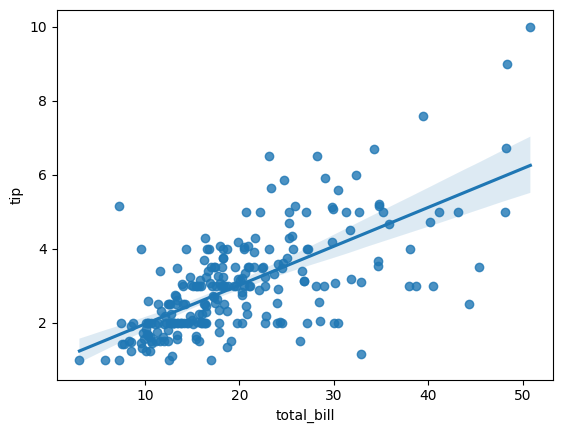

In [20]:
# regplot using axes level function
sns.regplot(data=tips, x='total_bill', y='tip')

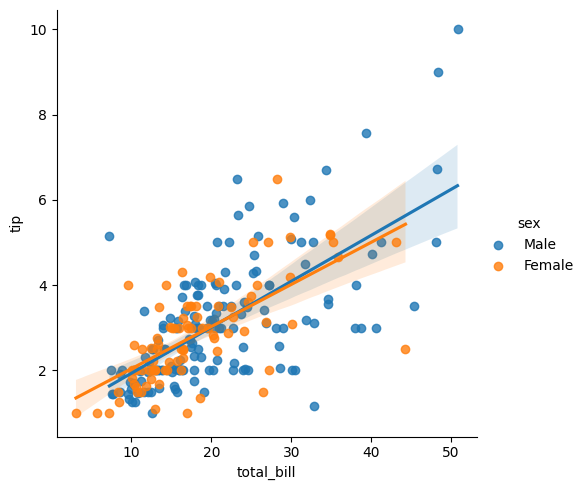

In [21]:
# regplot using figure level function
sns.lmplot(data=tips, x='total_bill', y='tip', hue='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

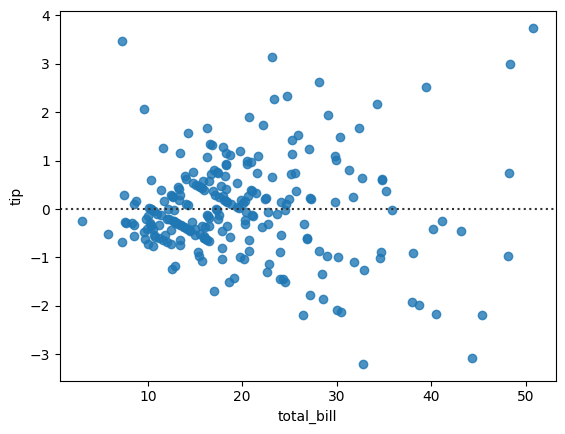

In [22]:
# residplot using axes level function
sns.residplot(data=tips, x='total_bill', y='tip')

## 6. Multi-Grid Plot

Multi-grid plots are advanced plotting structures provided by **Seaborn** that allow us to create multiple related visualizations within a structured grid layout. These are especially useful when we want to explore relationships across multiple variables simultaneously.

There are three important types of multi-grid plots:

* **FacetGrid**
* **PairGrid**
* **JointGrid**

---

### FacetGrid

Earlier, while using **`relplot`**, **`displot`**, and **`catplot`**, we had the option to create **facet plots** using the `row` and `col` parameters.

For example:

```python
sns.catplot(data=tips, x='sex', y='total_bill', kind='violin', col='day', row='time')
```

This creates multiple plots arranged in a grid based on the values of `day` (columns) and `time` (rows).

However, there is another method to create facet plots manually using **FacetGrid**.

```python
g = sns.FacetGrid(data=tips, col='day', row='time')
g.map(sns.violinplot, 'sex', 'total_bill', order=['Male', 'Female'])
```

#### How this works

1. `sns.FacetGrid()` first constructs an empty grid based on the categorical variables provided.
2. In this case, the grid size becomes:

```
number of days × number of time categories
```

3. The `g.map()` function is then used to draw a plot inside each cell of the grid.

So essentially:

* **FacetGrid → creates the grid**
* **map() → fills the grid with plots**

#### Important Note

For most common cases, **`catplot` is still the preferred and simpler approach**.

`FacetGrid` is mainly useful when we require **more control and customization** over how the plots are drawn.

---

## Plotting Pairwise Relationships

To analyze relationships between multiple numerical variables simultaneously, Seaborn provides two tools:

* **PairPlot**
* **PairGrid**

---

### PairPlot

A **pairplot** automatically plots the relationship between every pair of numerical variables in a dataset.

For example, consider the **iris dataset**, which contains **4 numerical variables**.

Pairplot will:

1. Automatically identify the **quantitative columns**.
2. Create a grid of:

```
number of numeric columns × number of numeric columns
```

In the iris dataset:

```
4 × 4 grid
```

Each cell represents the relationship between two variables.

* **Off-diagonal cells** → scatterplots showing relationships between two variables.
* **Diagonal cells** → distribution of a single variable.

Example:

```python
sns.pairplot(iris)
```

#### What happens in the diagonal?

Since the diagonal compares a variable **with itself**, plotting a scatterplot would not make sense.

Therefore:

* If **no hue is provided** → **Histogram** is plotted.
* If **hue is provided** → **KDE plot** is used.

The reason is that KDE allows smoother comparison between distributions of different categories.

Example:

```python
sns.pairplot(iris, hue='species')
```

Here, since `species` is a categorical variable, the diagonal uses **KDE plots** to clearly visualize overlapping distributions.

---

### PairGrid

Just like **facet plots are built on top of `FacetGrid`**, the **pairplot is built on top of `PairGrid`**.

PairGrid provides much **greater flexibility and customization**.

Example:

```python
g = sns.PairGrid(data=iris, hue='species')
g.map(sns.scatterplot)
```

This creates scatterplots for all grid sections.

---

#### Customizing Diagonal and Off-Diagonal Plots

We can control the plots separately.

```python
g = sns.PairGrid(data=iris, hue='species')
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
```

Here:

* **Diagonal** → Histogram
* **Off-diagonal** → Scatterplot

---

#### More Customization

We can also customize **upper**, **lower**, and **diagonal** sections separately.

```python
g = sns.PairGrid(data=iris, hue='species')
g.map_lower(sns.scatterplot)
g.map_upper(sns.histplot)
g.map_diag(sns.kdeplot)
```

This allows very fine-grained control over the visualization.

---

#### Limiting the Scope of Variables

Sometimes we may only want to visualize relationships between selected columns.

This can be done using the `vars` parameter.

```python
g = sns.PairGrid(data=iris, hue='species', vars=['petal_width', 'sepal_width'])
g.map_lower(sns.scatterplot)
g.map_upper(sns.histplot)
g.map_diag(sns.kdeplot)
```

This creates a grid only for the selected variables.

---

## JointPlot and JointGrid

These plots are used to visualize the relationship between **two variables**, along with their **individual distributions**.

---

### JointPlot

A **jointplot** shows:

* Relationship between two variables in the **center**
* Distribution of each variable on the **marginal axes**

Example:

```python
sns.jointplot(data=tips, x='total_bill', y='tip')
```

By default, this creates a **scatterplot** in the center and histograms on the margins.

---

#### KDE JointPlot

```python
sns.jointplot(data=tips, x='total_bill', y='tip', kind='kde')
```

This shows the relationship using **Kernel Density Estimation**, which visualizes the density of data points.

---

#### Hex JointPlot

```python
sns.jointplot(data=tips, x='total_bill', y='tip', kind='hex')
```

Here the plot uses **hexagonal bins** to represent density. This is useful when the dataset is large and scatterplots become cluttered.

---

### JointGrid

Just like other grid classes, **JointGrid provides greater flexibility than JointPlot**.

It allows us to manually specify which plots should appear in:

* the **central joint area**
* the **marginal distributions**

Example:

```python
g = sns.JointGrid(data=tips, x='total_bill', y='tip')
g.plot(sns.scatterplot, sns.boxplot)
```

Here:

* **Center plot** → Scatterplot
* **Marginal plots** → Boxplots

This flexibility allows much more customized visualization layouts.

---

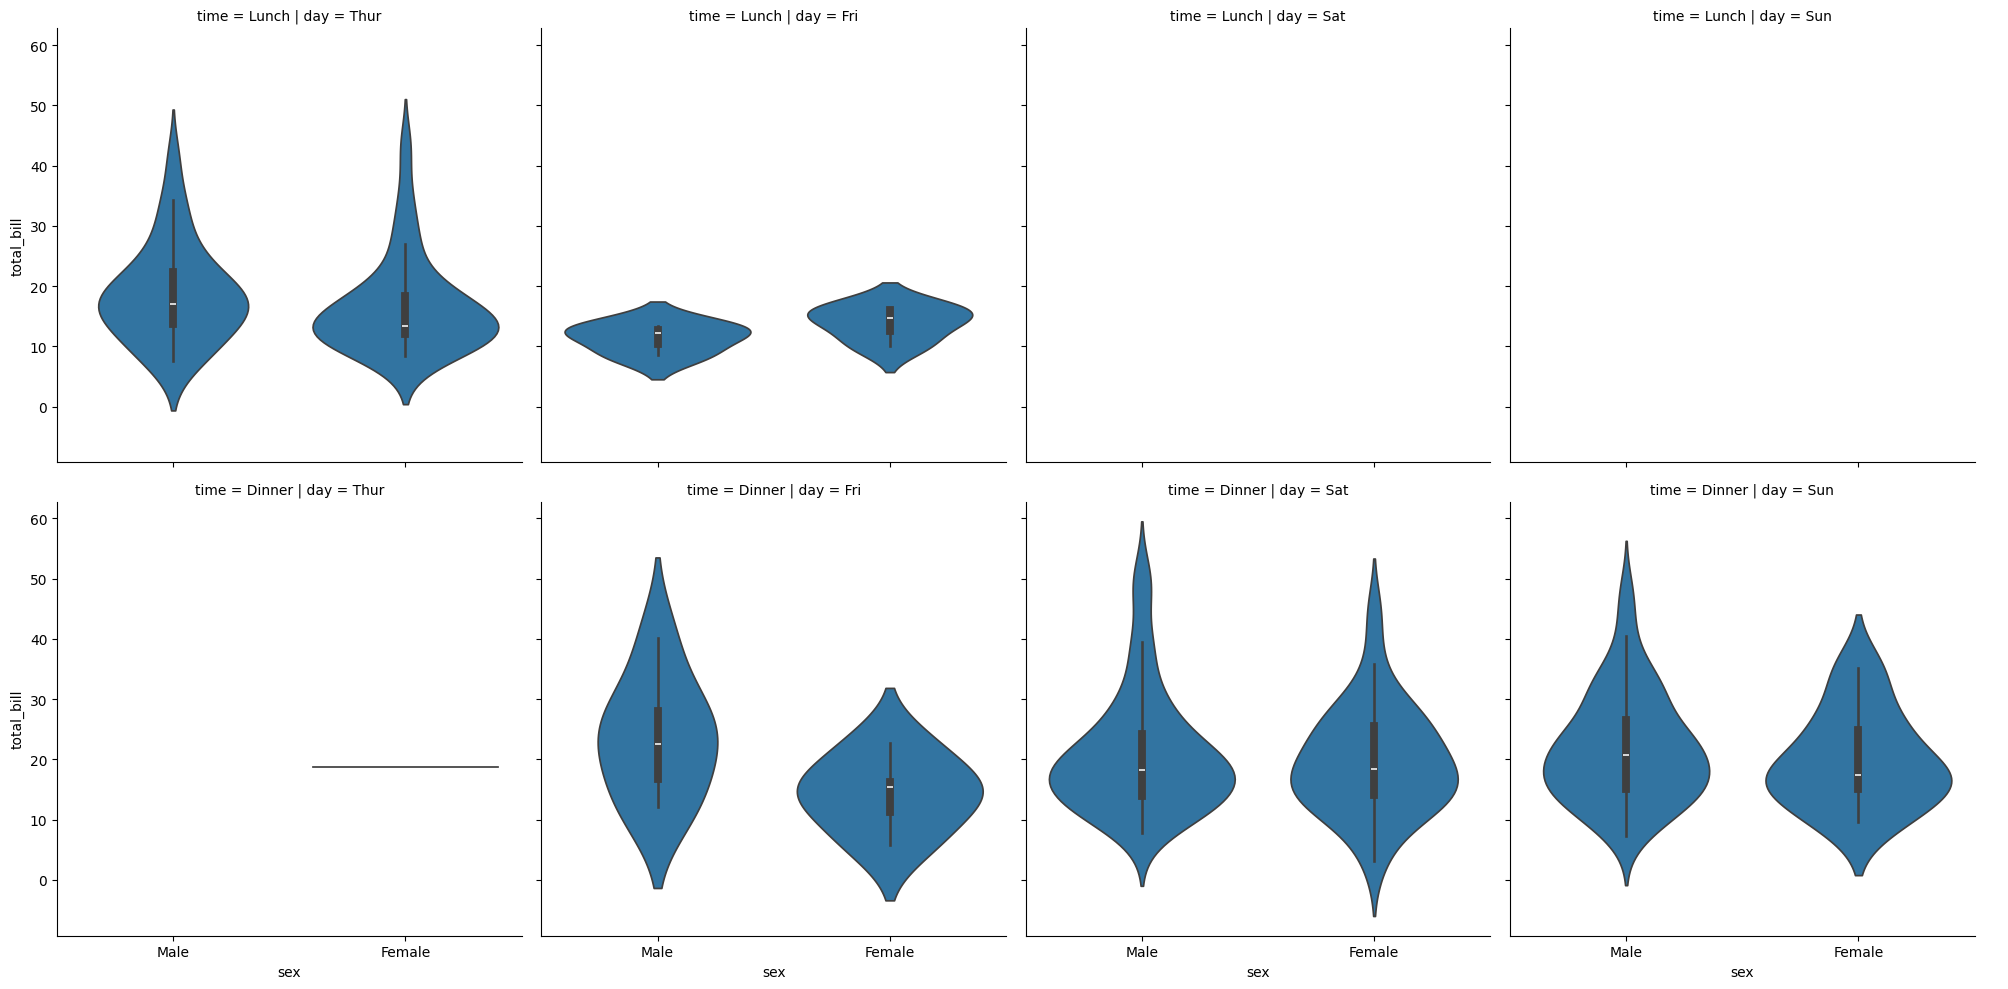

In [23]:
# facet plot using the conventional seaborn method.
sns.catplot(data=tips, x='sex', y='total_bill', kind='violin', col='day', row='time')

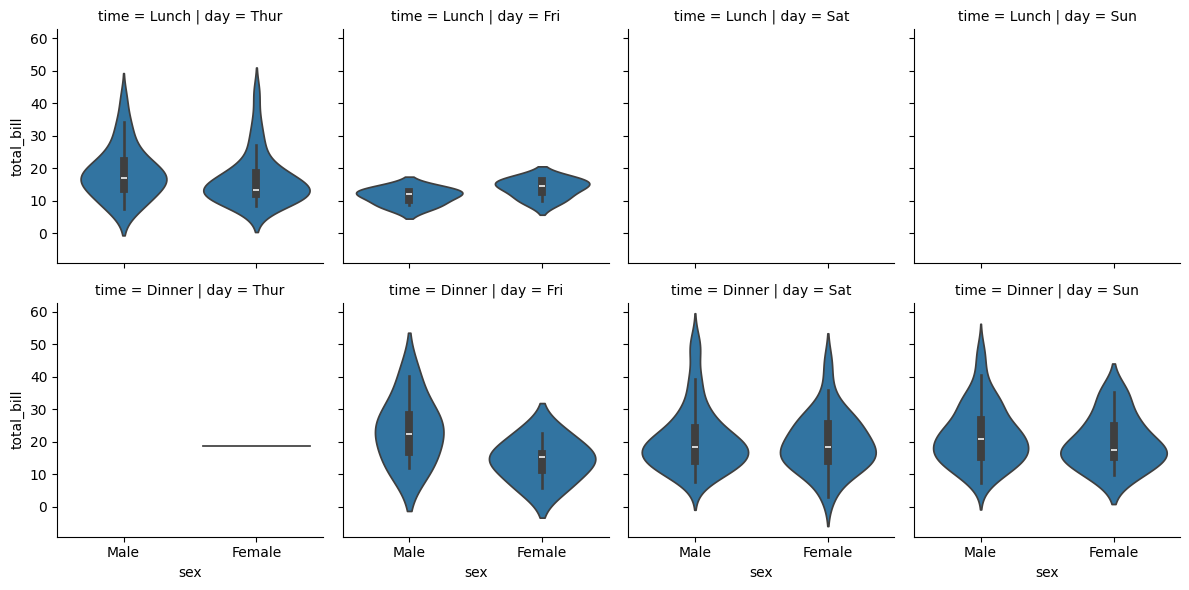

In [24]:
g = sns.FacetGrid(data=tips, col='day', row='time')
g.map(sns.violinplot, 'sex', 'total_bill', order=['Male', 'Female'])

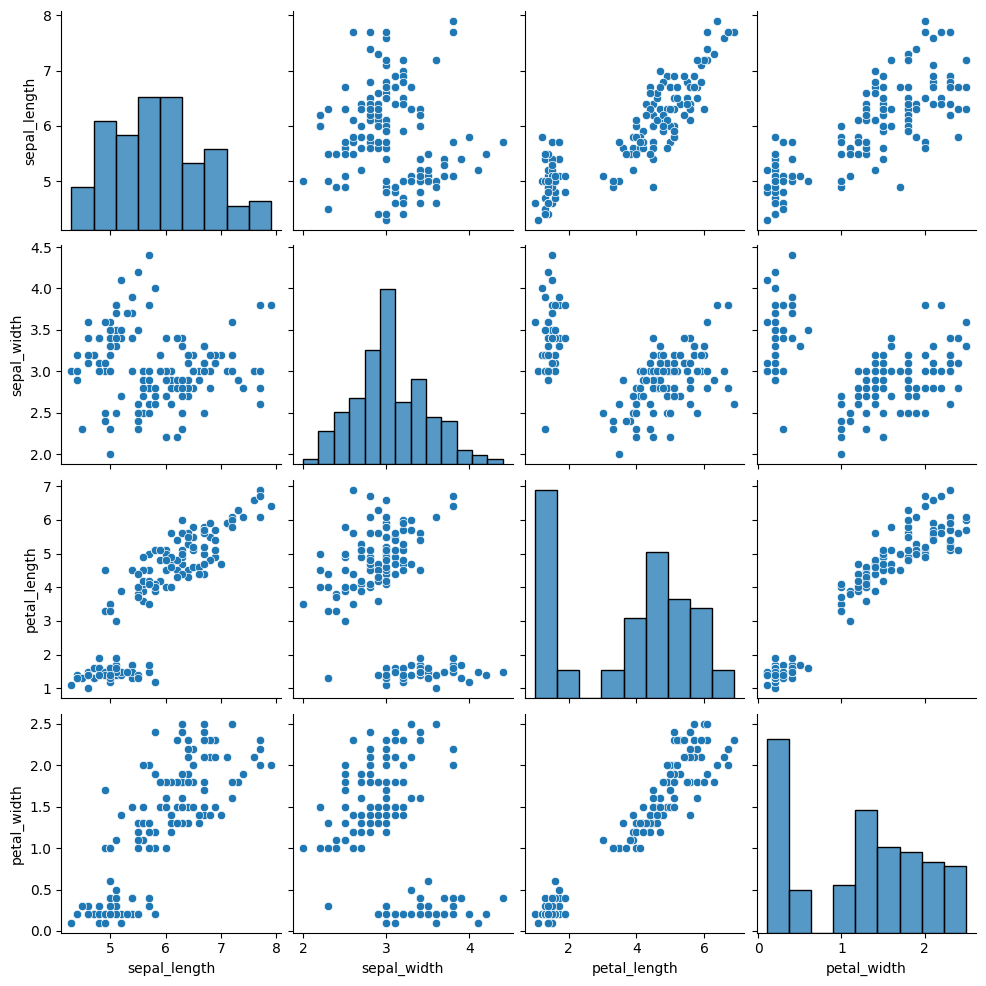

In [ ]:
# pairplot using axes level function
sns.pairplot(iris)

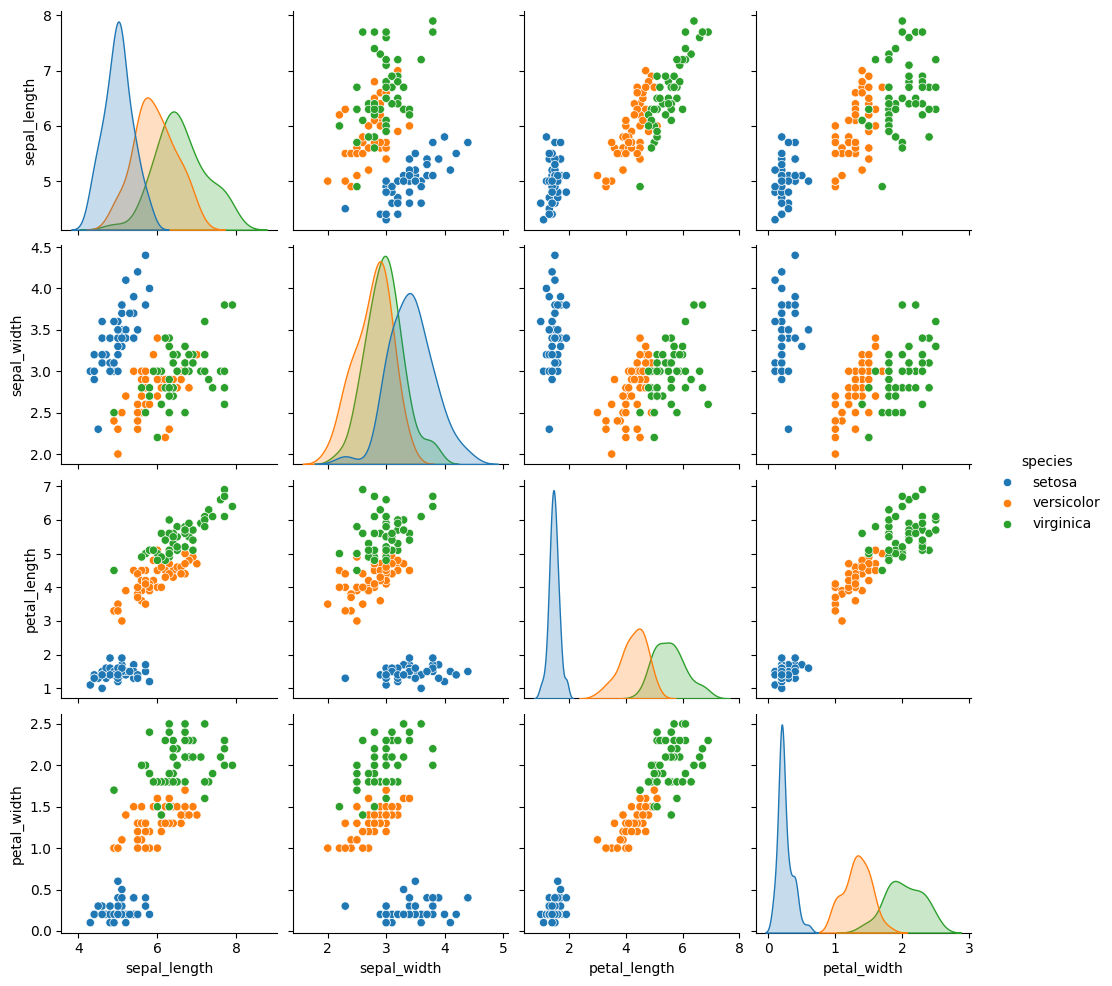

In [ ]:
# paitplot with added hue. Multiple categorical vars in species cause
# kde plot formation at diagonal for better overview.
sns.pairplot(iris, hue='species')

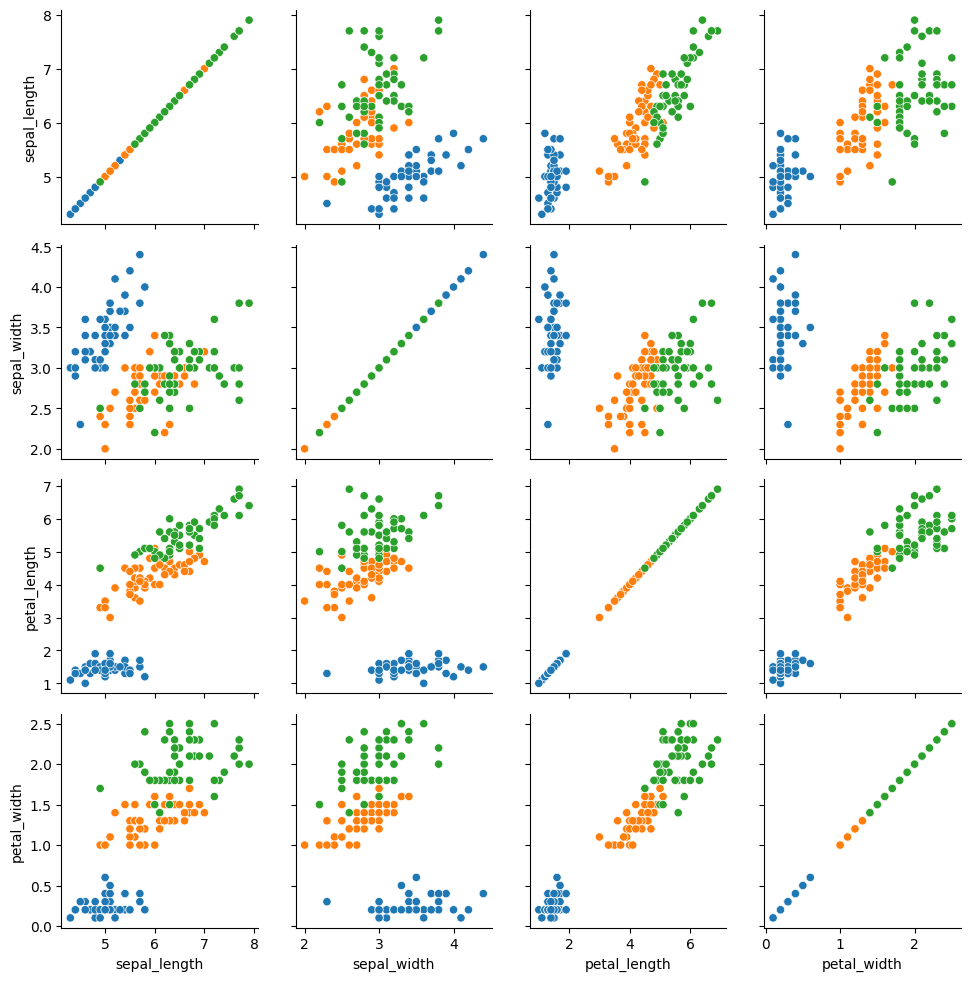

In [31]:
# pairgrid
g = sns.PairGrid(data=iris, hue='species')
g.map(sns.scatterplot)

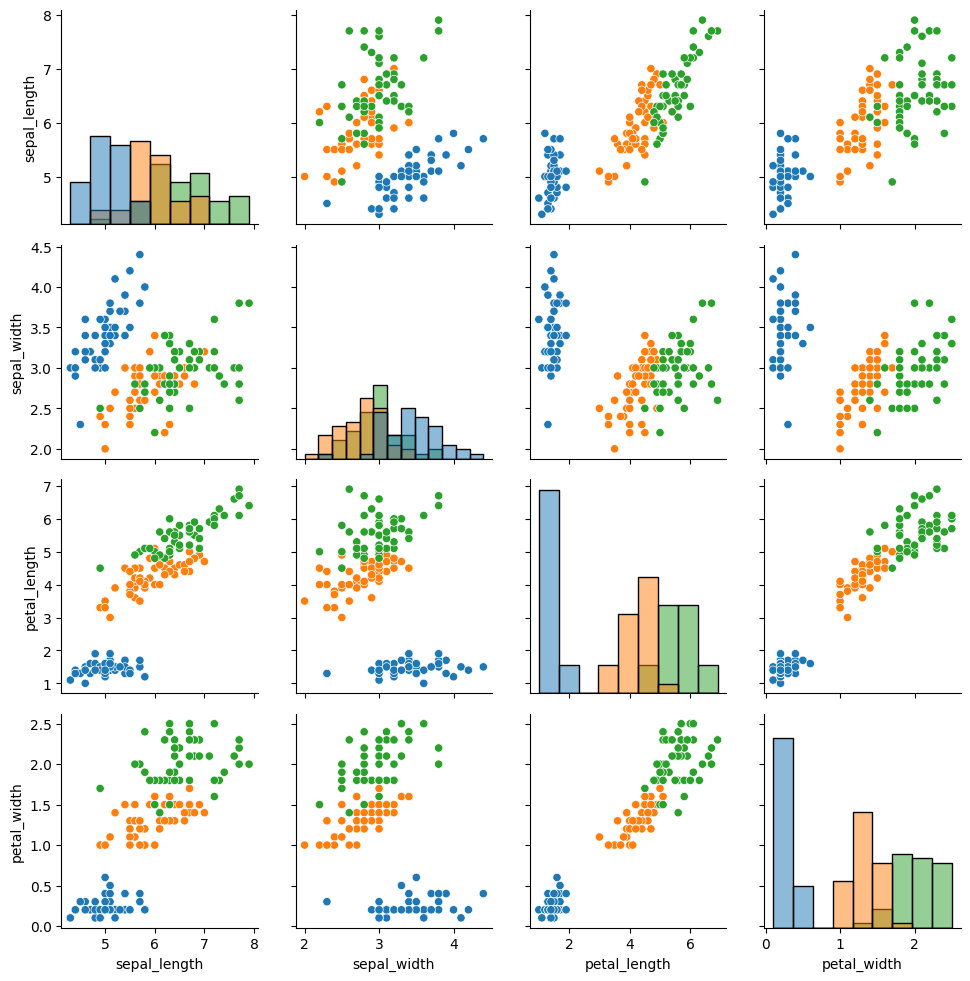

In [35]:
g = sns.PairGrid(data=iris, hue='species')
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

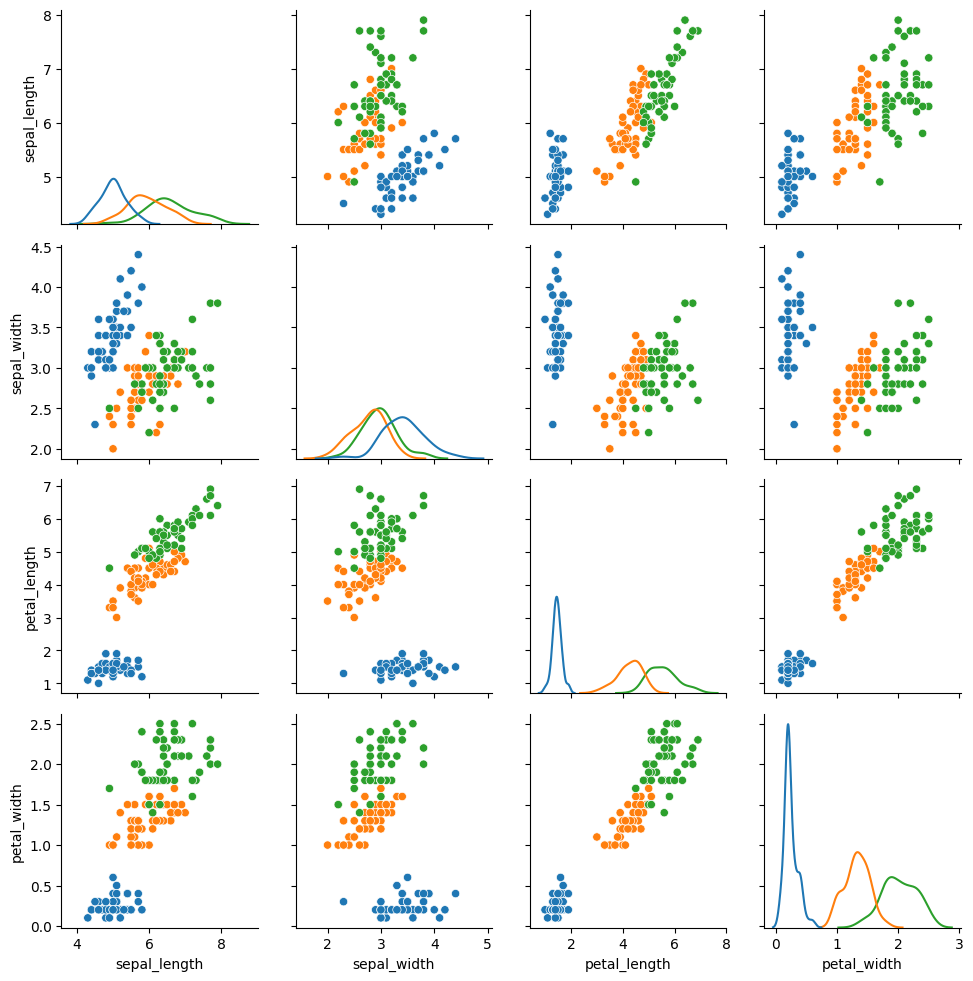

In [34]:
g = sns.PairGrid(data=iris, hue='species')
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.scatterplot)

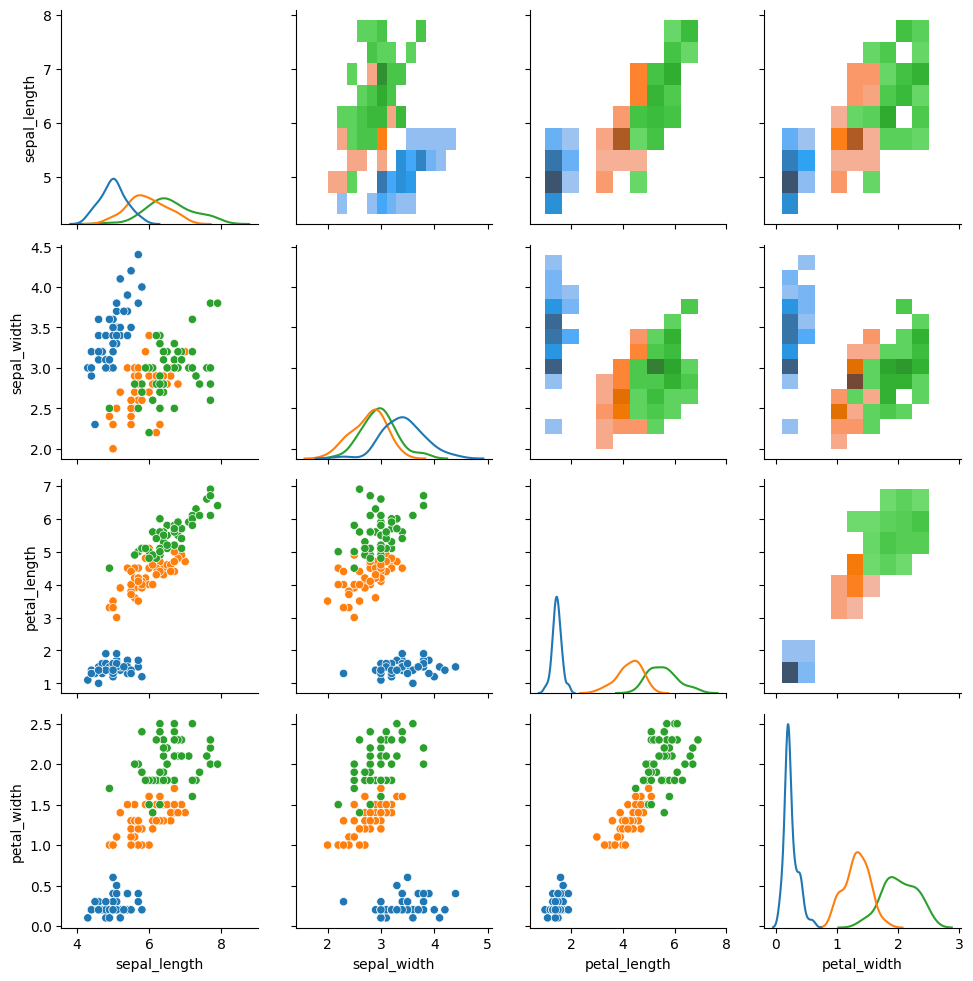

In [ ]:
# more customizations with PairGrid
g = sns.PairGrid(data=iris, hue='species')
g.map_lower(sns.scatterplot)
g.map_upper(sns.histplot)
g.map_diag(sns.kdeplot)

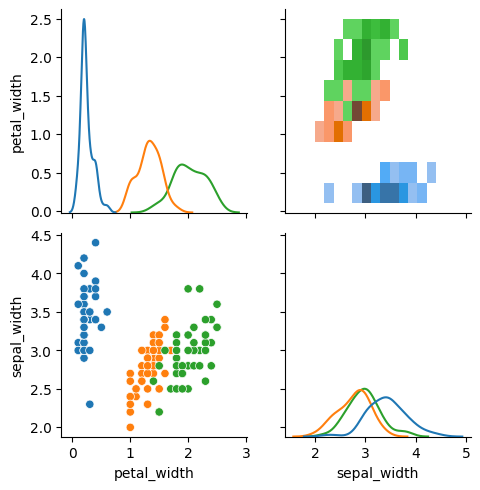

In [41]:
# limiting scope of vars
g = sns.PairGrid(data=iris, hue='species', vars=['petal_width', 'sepal_width'])
g.map_lower(sns.scatterplot)
g.map_upper(sns.histplot)
g.map_diag(sns.kdeplot)

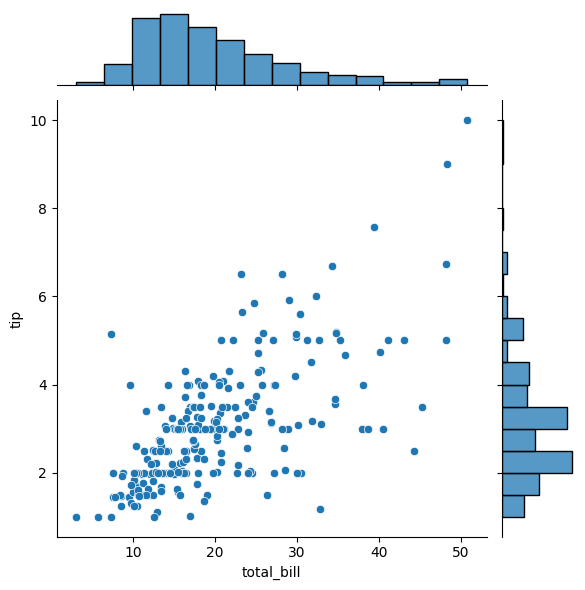

In [ ]:
# jointplot using axes level function
# by default scatterplot is created
sns.jointplot(data=tips, x='total_bill', y='tip')

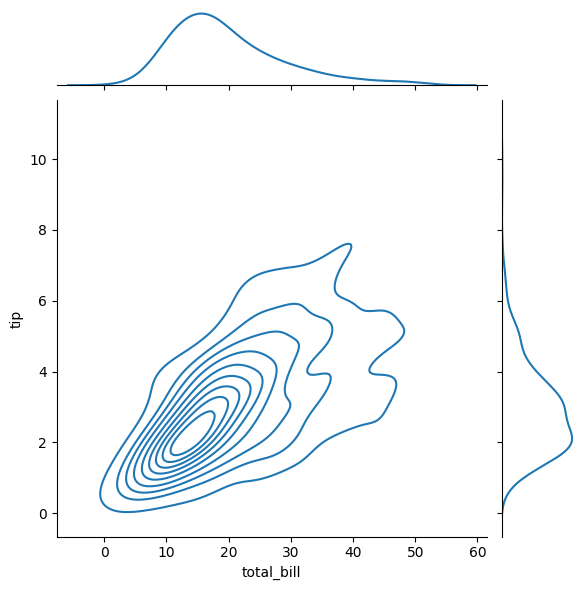

In [44]:
# kdeplot in jointplot
sns.jointplot(data=tips, x='total_bill', y='tip', kind='kde')

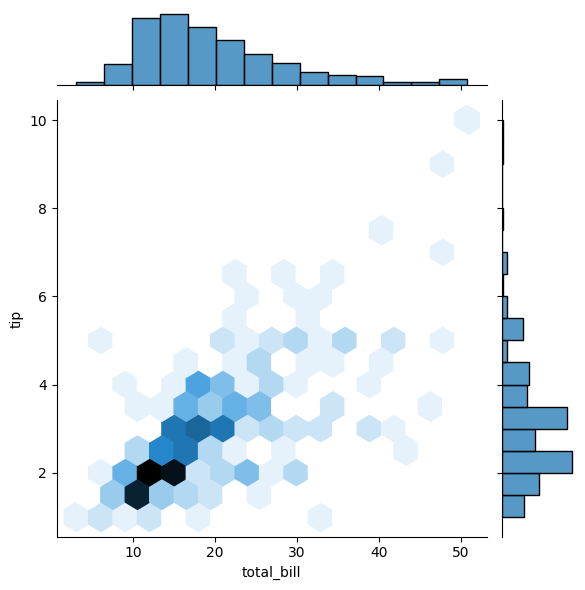

In [ ]:
# hexplot in jointplot
sns.jointplot(data=tips, x='total_bill', y='tip', kind='hex')

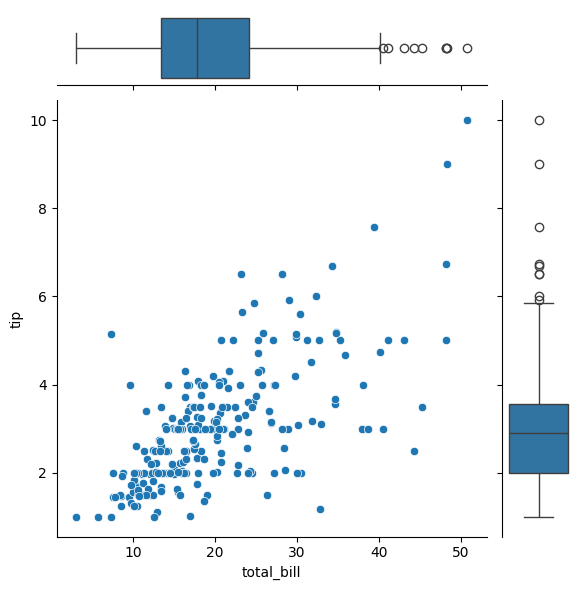

In [ ]:
# customization using JointGrid
g = sns.JointGrid(data=tips, x='total_bill', y='tip')
g.plot(sns.scatterplot, sns.boxplot)